# Staggered-grid (WRF) NetCDF files

WRF model output with mass and staggered (`*_stag`) dimensions and string bookkeeping variables. Inspection, plotting, retrieval, and variable mutation; affine polygon crop does not apply.

In [1]:
%matplotlib inline
import tempfile
from pathlib import Path

import geopandas as gpd
import numpy as np
from shapely.geometry import Polygon

from pyramids.feature import FeatureCollection
from pyramids.netcdf import GeoReference, NetCDF
from pyramids.netcdf.plot_options import Selectors

DATA = Path('../../../../examples/data/netcdf/samples')

## `none__17v__1d1-2d5-3d6-4d5__stag-str.nc`

WRF surface/3-D fields on mass and staggered grids (T2 = 2 m temperature).

**Open the file and inspect the container**

In [2]:
nc = NetCDF.read_file(DATA / 'none__17v__1d1-2d5-3d6-4d5__stag-str.nc')
nc

Driver: netCDF/Network Common Data Format
Files: ..\..\..\..\examples\data\netcdf\samples\none__17v__1d1-2d5-3d6-4d5__stag-str.nc
       ..\..\..\..\examples\data\netcdf\samples\none__17v__1d1-2d5-3d6-4d5__stag-str.nc.aux.xml
Size is 512, 512
Corner Coordinates:
Upper Left  (    0.0,    0.0)
Lower Left  (    0.0,  512.0)
Upper Right (  512.0,    0.0)
Lower Right (  512.0,  512.0)
Center      (  256.0,  256.0)

**Dimensions and variables**

In [3]:
# get_all_metadata() returns a NetCDFMetadata whose summary lists dimensions and, for each
# variable, its dims / shape / dtype / unit / scale-offset.
meta = nc.get_all_metadata()
print(meta)

NetCDFMetadata
  Driver: netCDF
  Root group: /
  Dimensions (9):
    Time                 size=3
    bottom_top           size=27
    bottom_top_stag      size=28
    ext_scalar           size=1
    soil_layers_stag     size=5
    south_north          size=60
    south_north_stag     size=61
    west_east            size=73
    west_east_stag       size=74
  Variables (17):
    ITIMESTEP dims=('/Time', '/ext_scalar') shape=(3, 1) dtype=int32
    IVGTYP dims=('/Time', '/south_north', '/west_east') shape=(3, 60, 73) dtype=int32
    MAPFAC_U dims=('/Time', '/south_north', '/west_east_stag') shape=(3, 60, 74) dtype=float32
    MAPFAC_V dims=('/Time', '/south_north_stag', '/west_east') shape=(3, 61, 73) dtype=float32
    P_TOP dims=('/Time', '/ext_scalar') shape=(3, 1) dtype=float32 unit='Pa'
    SMOIS dims=('/Time', '/soil_layers_stag', '/south_north', '/west_east') shape=(3, 5, 60, 73) dtype=float32 unit='m3 m-3'
    T dims=('/Time', '/bottom_top', '/south_north', '/west_east') shape=(3,

**Global attributes**

In [4]:
nc.global_attributes

{'BL_PBL_PHYSICS': 1,
 'BOTTOM-TOP_GRID_DIMENSION': 28,
 'BOTTOM-TOP_PATCH_END_STAG': 28,
 'BOTTOM-TOP_PATCH_END_UNSTAG': 27,
 'BOTTOM-TOP_PATCH_START_STAG': 1,
 'BOTTOM-TOP_PATCH_START_UNSTAG': 1,
 'CEN_LAT': 34.83157730102539,
 'CEN_LON': -81.02755737304688,
 'CU_PHYSICS': 1,
 'DAMP_OPT': 0,
 'DIFF_OPT': 0,
 'DT': 180.0,
 'DX': 30000.0,
 'DY': 30000.0,
 'DYN_OPT': 2,
 'GMT': 12.0,
 'GRIDTYPE': 'C',
 'ISICE': 24,
 'ISOILWATER': 14,
 'ISURBAN': 1,
 'ISWATER': 16,
 'JULDAY': 24,
 'JULYR': 2000,
 'KHDIF': 0.0,
 'KM_OPT': 1,
 'KVDIF': 0.0,
 'MAP_PROJ': 1,
 'MMINLU': 'USGS',
 'MOAD_CEN_LAT': 34.83157730102539,
 'MP_PHYSICS': 3,
 'RA_LW_PHYSICS': 1,
 'RA_SW_PHYSICS': 1,
 'SF_SFCLAY_PHYSICS': 1,
 'SF_SURFACE_PHYSICS': 1,
 'SOUTH-NORTH_GRID_DIMENSION': 61,
 'SOUTH-NORTH_PATCH_END_STAG': 61,
 'SOUTH-NORTH_PATCH_END_UNSTAG': 60,
 'SOUTH-NORTH_PATCH_START_STAG': 1,
 'SOUTH-NORTH_PATCH_START_UNSTAG': 1,
 'STAND_LON': -98.0,
 'START_DATE': '2000-01-24_12:00:00',
 'TITLE': ' OUTPUT FROM WRF V2.0 MO

**Plot the variable.** One WRF quirk to know: diagnostic 2-m fields (`T2`, `Q2`, `U10`, `V10`) are
**all zeros at the initialization time** — the surface-layer scheme has not run yet — so plotting the
default first step renders a single flat colour. Select a real time step with `Selectors(isel=...)`.

<Axes: >

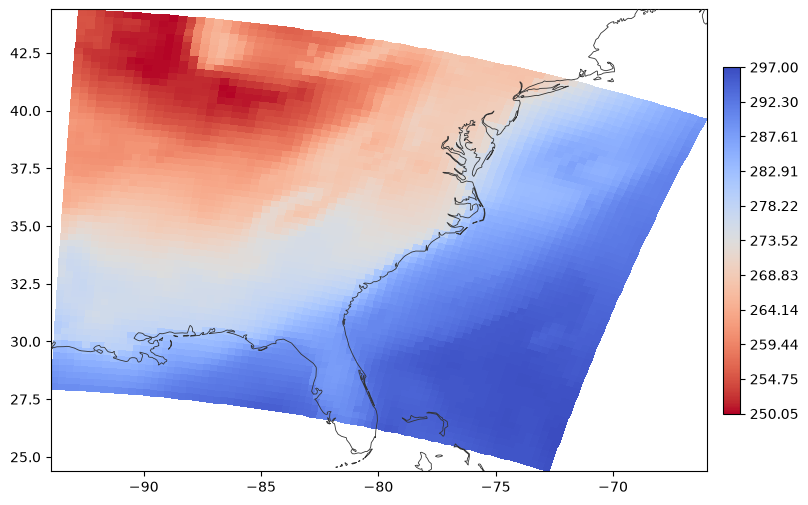

In [5]:
glyph = nc.plot(variable='T2', selectors=Selectors(isel={'Time': 1}))
# overlay the Natural Earth coastline for geographic context — the glyph carries
# the data CRS (issue #630), so no crs= is needed to line it up
glyph.add_features("coastline", "50m", zorder=5)

**Retrieve the underlying data**

In [6]:
var = nc.get_variable('T2')
data = var.read_array()
print('shape:', data.shape)
print(
    'min / mean / max:',
    float(np.nanmin(data)),
    float(np.nanmean(data)),
    float(np.nanmax(data)),
)

shape: (3, 60, 73)
min / mean / max: 0.0 185.22796630859375 297.0773620605469


**Add a variable** — derive a 2-D field and append it as a new variable

In [7]:
work = Path(tempfile.mkdtemp())
slice2d = data[tuple(0 for _ in range(data.ndim - 2))]
NetCDF.create_from_array(
    arr=slice2d,
    geo_ref=GeoReference(geo=(0.0, 1.0, 0.0, 0.0, 0.0, -1.0), epsg=var.epsg or 4326),
    variable_name='T2_slice0',
    path=str(work / 'derived.nc'),
)
nc.add_variable(NetCDF.read_file(str(work / 'derived.nc')), 'T2_slice0')
print('variables after add:', nc.variable_names)

variables after add: ['ITIMESTEP', 'IVGTYP', 'MAPFAC_U', 'MAPFAC_V', 'P_TOP', 'SMOIS', 'T', 'T2', 'T2_slice0', 'Times', 'U', 'V', 'W', 'XLAT', 'XLONG', 'ZNU', 'ZNW', 'ZS']


**Remove a variable**

In [8]:
nc.remove_variable('T2_slice0')
print('variables after remove:', nc.variable_names)

variables after remove: ['ITIMESTEP', 'IVGTYP', 'MAPFAC_U', 'MAPFAC_V', 'P_TOP', 'SMOIS', 'T', 'T2', 'Times', 'U', 'V', 'W', 'XLAT', 'XLONG', 'ZNU', 'ZNW', 'ZS']


**Crop with a polygon** — WRF output is on a **staggered, map-projected** grid, but its cell centres carry 2-D geolocation (`XLAT(y, x)` / `XLONG(y, x)`). `crop` masks on those 2-D coordinates (the same path as the ROMS curvilinear example), so a polygon crop works and the result stays curvilinear.

cropped shape: (3, 32, 41)


<Axes: >

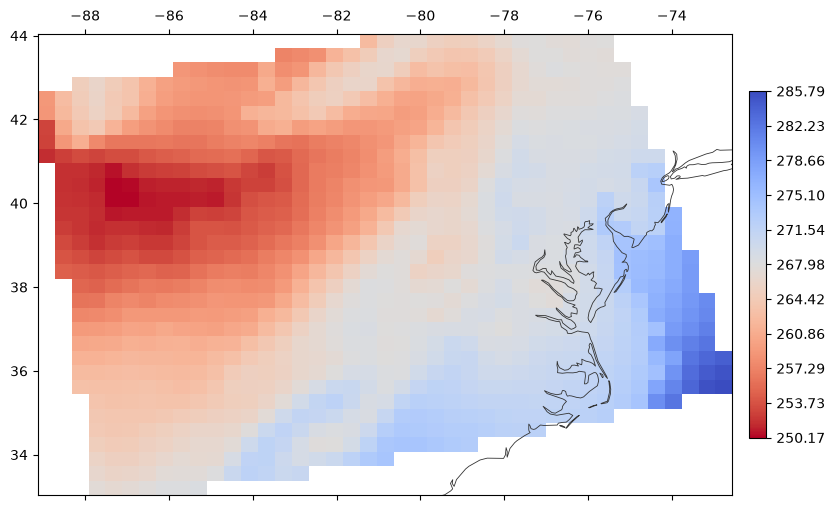

In [9]:
# the WRF domain spans roughly lon -94..-66, lat 25..44; crop to a box over the north-eastern US
aoi = FeatureCollection(
    gpd.GeoDataFrame(
        geometry=[Polygon([(-88, 35), (-75, 35), (-75, 43), (-88, 43)])], crs=4326
    )
)
t2 = nc.get_variable('T2')
cropped = t2.crop(aoi)
print('cropped shape:', cropped.shape)
# T2 is zero at the initialization step (see above) -- plot the first real one.
# crop returns a plain variable whose band dim is normalized to lowercase 'time'.
glyph = cropped.plot(selectors=Selectors(isel={'time': 1}))
# overlay the coastline so the cropped WRF patch is easy to place
glyph.add_features("coastline", "50m", zorder=5)

**Save the container to a new NetCDF file**

In [10]:
out = work / 'saved.nc'
nc.to_file(out)
print('saved container to', out.name, '->', out.exists())

saved container to saved.nc -> True
